# Lab 11 UC1: LangGraph + SAP AI Core + S/4HANA
## Production-Ready SAP Procurement Agent

**Learning Objectives:**
- Build a LangGraph agent with state machine architecture
- Integrate with S/4HANA OData APIs for purchase order data
- Implement RAG for policy document retrieval
- Add Human-in-the-Loop (HITL) with SAP Build Process Automation
- Apply guardrails for input validation and PII masking

**Architecture:**
```
User Query → Guardrails → Router → [RAG | Tools | Response]
                                       ↓
                                    HITL Check → BPA Workflow
                                       ↓
                                   Response → User
```

**Prerequisites:**
- Python 3.10+
- `.env` file with credentials
- S/4HANA access
- OpenAI API key
- (Optional) SAP BPA credentials

---
## Part 1: Environment Setup

In [1]:
# Install dependencies (run once)
# Core packages
# !pip install langgraph langchain langchain-openai langchain-community chromadb httpx python-dotenv openai

# For graph visualization in Jupyter (required for draw_mermaid_png)
# !pip install grandalf

In [2]:
import os
import re
import json
import uuid
from typing import TypedDict, Annotated, List, Optional, Tuple
from dotenv import load_dotenv

# LangGraph imports
from langgraph.graph import StateGraph, END, add_messages
from langgraph.checkpoint.memory import MemorySaver

# LangChain imports
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.tools import tool
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

# HTTP client for S/4HANA
import httpx

# OpenAI for LLM-based routing
from openai import OpenAI

# Load environment variables
load_dotenv()

print("Imports successful!")

Imports successful!


In [3]:
def verify_environment():
    """Check all required environment variables."""
    required_vars = [
        'S4HANA_BASE_URL',
        'S4HANA_USER',
        'S4HANA_PASSWORD',
        'OPENAI_API_KEY',
    ]
    
    optional_vars = [
        'BPA_API_URL',
        'BPA_CLIENT_ID',
        'BPA_CLIENT_SECRET',
        'BPA_DEFINITION_ID',
        'REQUESTOR_EMAIL',
        'HITL_APPROVAL_THRESHOLD',
        'LANGCHAIN_API_KEY',
    ]
    
    print("=" * 50)
    print("ENVIRONMENT CHECK")
    print("=" * 50)
    
    missing = []
    for var in required_vars:
        value = os.getenv(var)
        if value:
            masked = '****' if any(x in var for x in ['PASSWORD', 'SECRET', 'KEY']) else value[:30]
            print(f"  [OK] {var}: {masked}")
        else:
            print(f"  [MISSING] {var}")
            missing.append(var)
    
    print("\nOptional:")
    for var in optional_vars:
        status = "[SET]" if os.getenv(var) else "[NOT SET]"
        print(f"  {status} {var}")
    
    bpa_configured = all([os.getenv(v) for v in ['BPA_API_URL', 'BPA_CLIENT_ID', 'BPA_CLIENT_SECRET', 'BPA_DEFINITION_ID']])
    print(f"\nSAP BPA Integration: {'ENABLED' if bpa_configured else 'DISABLED'}")
    
    return len(missing) == 0

verify_environment()

ENVIRONMENT CHECK
  [OK] S4HANA_BASE_URL: http://mtsapserver3.themdlabs.
  [OK] S4HANA_USER: sdasari
  [OK] S4HANA_PASSWORD: ****
  [OK] OPENAI_API_KEY: ****

Optional:
  [SET] BPA_API_URL
  [SET] BPA_CLIENT_ID
  [SET] BPA_CLIENT_SECRET
  [SET] BPA_DEFINITION_ID
  [SET] REQUESTOR_EMAIL
  [SET] HITL_APPROVAL_THRESHOLD
  [SET] LANGCHAIN_API_KEY

SAP BPA Integration: ENABLED


True

---
## Part 2: Agent State Definition

**Key Concept:** LangGraph uses a TypedDict to define the state that flows through the graph. The `add_messages` annotation ensures messages are appended, not replaced.

In [4]:
class AgentState(TypedDict):
    """
    State that flows through our procurement agent.
    
    The 'add_messages' annotation appends new messages
    instead of replacing the list (maintains conversation history).
    """
    
    # Core conversation
    messages: Annotated[List[BaseMessage], add_messages]
    
    # Intent classification
    intent: Optional[str]  # 'po_query', 'policy_lookup', 'general'
    
    # Tool execution results
    tool_results: Optional[dict]
    
    # RAG context from policy lookup
    rag_context: Optional[str]
    
    # Human-in-the-Loop
    requires_approval: bool
    approval_status: Optional[str]  # 'pending', 'approved', 'rejected'
    approval_reason: Optional[str]
    
    # PO metadata
    po_number: Optional[str]
    po_amount: Optional[float]

print("AgentState defined with fields:")
for field, field_type in AgentState.__annotations__.items():
    print(f"  - {field}: {field_type}")

AgentState defined with fields:
  - messages: typing.Annotated[typing.List[langchain_core.messages.base.BaseMessage], <function _add_messages_wrapper.<locals>._add_messages at 0x000002318248D760>]
  - intent: typing.Optional[str]
  - tool_results: typing.Optional[dict]
  - rag_context: typing.Optional[str]
  - requires_approval: <class 'bool'>
  - approval_status: typing.Optional[str]
  - approval_reason: typing.Optional[str]
  - po_number: typing.Optional[str]
  - po_amount: typing.Optional[float]


---
## Part 3: S/4HANA Client & Tools

**Key Concept:** Tools are Python functions decorated with `@tool`. They are automatically converted to OpenAI function calling format.

In [5]:
class S4HANAClient:
    """Client for S/4HANA OData APIs."""
    
    def __init__(self):
        self.base_url = os.getenv('S4HANA_BASE_URL')
        self.user = os.getenv('S4HANA_USER')
        self.password = os.getenv('S4HANA_PASSWORD')
        
    def get_purchase_order(self, po_number: str) -> dict:
        """Fetch a single PO with item-level amounts."""
        url = f"{self.base_url}/sap/opu/odata/sap/API_PURCHASEORDER_PROCESS_SRV/A_PurchaseOrder('{po_number}')?$expand=to_PurchaseOrderItem"
        
        try:
            response = httpx.get(
                url,
                auth=(self.user, self.password),
                headers={'Accept': 'application/json'},
                timeout=30.0
            )
            
            if response.status_code == 200:
                data = response.json().get('d', {})
                
                # Calculate total amount from items
                items = data.get('to_PurchaseOrderItem', {}).get('results', [])
                total_amount = sum(
                    float(item.get('NetPriceAmount', 0) or 0) * float(item.get('OrderQuantity', 1) or 1)
                    for item in items
                )
                
                return {
                    'po_number': data.get('PurchaseOrder'),
                    'vendor': data.get('Supplier'),
                    'vendor_name': data.get('AddressName', 'N/A'),
                    'amount': total_amount,
                    'currency': data.get('DocumentCurrency'),
                    'status': data.get('PurchasingProcessingStatus', 'N/A'),
                    'company_code': data.get('CompanyCode'),
                    'item_count': len(items)
                }
            elif response.status_code == 404:
                return {'error': f'PO {po_number} not found'}
            else:
                return {'error': f'API error: {response.status_code}'}
                
        except Exception as e:
            return {'error': f'Connection error: {str(e)}'}
    
    def list_purchase_orders(self, top: int = 5) -> list:
        """List recent POs with calculated amounts."""
        url = f"{self.base_url}/sap/opu/odata/sap/API_PURCHASEORDER_PROCESS_SRV/A_PurchaseOrder"
        params = {'$top': top, '$format': 'json', '$expand': 'to_PurchaseOrderItem'}
        
        try:
            response = httpx.get(
                url,
                params=params,
                auth=(self.user, self.password),
                timeout=60.0
            )
            
            if response.status_code == 200:
                results = response.json().get('d', {}).get('results', [])
                po_list = []
                
                for po in results:
                    items = po.get('to_PurchaseOrderItem', {}).get('results', [])
                    total_amount = sum(
                        float(item.get('NetPriceAmount', 0) or 0) * float(item.get('OrderQuantity', 1) or 1)
                        for item in items
                    )
                    
                    po_list.append({
                        'po_number': po.get('PurchaseOrder'),
                        'vendor': po.get('Supplier'),
                        'vendor_name': po.get('AddressName', 'N/A'),
                        'amount': total_amount,
                        'currency': po.get('DocumentCurrency'),
                        'item_count': len(items)
                    })
                
                return po_list
            return []
            
        except Exception as e:
            return [{'error': str(e)}]

# Initialize client
s4_client = S4HANAClient()
print(f"S/4HANA Client initialized")
print(f"  Base URL: {s4_client.base_url}")

S/4HANA Client initialized
  Base URL: http://mtsapserver3.themdlabs.com:8003


In [6]:
# Test S/4HANA connection
print("Testing S/4HANA connection...")
pos = s4_client.list_purchase_orders(top=3)
print(f"\nFound {len(pos)} POs:")
for po in pos:
    print(f"  {po.get('po_number')}: ${po.get('amount', 0):,.2f} - {po.get('vendor_name', 'N/A')}")

Testing S/4HANA connection...

Found 3 POs:
  4500000001: $211,949.01 - USSU-VSF04
  4500000002: $101,080.63 - WaveCrest Labs
  4500000003: $20,878.73 - EV Parts Inc.


In [7]:
# Define LangChain tools
@tool
def get_purchase_order(po_number: str) -> dict:
    """
    Fetch a Purchase Order from S/4HANA by PO number.
    
    Args:
        po_number: The purchase order number (e.g., '4500000001')
    
    Returns:
        Dictionary with PO details including vendor, amount, status
    """
    return s4_client.get_purchase_order(po_number)


@tool
def list_purchase_orders(count: int = 5) -> list:
    """
    List recent Purchase Orders from S/4HANA.
    
    Args:
        count: Number of POs to return (default 5)
    
    Returns:
        List of PO summaries
    """
    return s4_client.list_purchase_orders(top=count)


@tool
def calculate_po_value(po_number: str) -> dict:
    """
    Get the total value of a Purchase Order for approval checks.
    
    Args:
        po_number: The purchase order number
    
    Returns:
        Dictionary with amount and currency
    """
    po = s4_client.get_purchase_order(po_number)
    if 'error' in po:
        return po
    return {
        'po_number': po_number,
        'amount': float(po.get('amount', 0) or 0),
        'currency': po.get('currency', 'USD')
    }

# Collect tools
tools = [get_purchase_order, list_purchase_orders, calculate_po_value]
print(f"Defined {len(tools)} tools: {[t.name for t in tools]}")

Defined 3 tools: ['get_purchase_order', 'list_purchase_orders', 'calculate_po_value']


---
## Part 4: RAG System (ChromaDB + OpenAI Embeddings)

**Key Concept:** RAG (Retrieval Augmented Generation) grounds the agent's responses in actual policy documents.

In [8]:
# Sample procurement policies
PROCUREMENT_POLICIES = """
# Procurement Policy Manual

## Purchase Order Approval Thresholds

The following approval levels apply to all purchase orders:

- Orders under $10,000: Auto-approved by system
- Orders $10,000 to $50,000: Requires manager approval
- Orders $50,000 to $100,000: Requires director approval  
- Orders over $100,000: Requires VP approval
- Orders over $500,000: Requires CFO approval

## Vendor Requirements

All vendors must meet these requirements before purchase orders can be issued:

1. Must be registered in SAP Vendor Master
2. Must have valid tax identification on file
3. Must complete annual compliance certification
4. Must maintain current insurance certificates
5. Must pass financial stability assessment for orders over $100,000

## Emergency Purchases

Emergency purchases may bypass standard approval workflow under these conditions:

- Documented business justification must be provided
- CFO must be notified within 24 hours
- Retroactive approval must be obtained within 5 business days
- Maximum emergency purchase amount: $25,000

## Payment Terms

Standard payment terms by vendor category:

- Strategic vendors: Net 60
- Preferred vendors: Net 45
- Standard vendors: Net 30
- New vendors (first 6 months): Net 15

## Compliance Requirements

All purchases must comply with:

- SOX controls for financial reporting
- GDPR requirements for data-related purchases
- Export control regulations for international vendors
- Anti-bribery and corruption policies

## Three-Way Match

All invoices require three-way match:
1. Purchase Order
2. Goods Receipt
3. Vendor Invoice

Tolerance levels:
- Quantity variance: +/-5%
- Price variance: +/-2%
"""

print(f"Policy document: {len(PROCUREMENT_POLICIES)} characters")

Policy document: 1660 characters


In [9]:
def initialize_rag():
    """Initialize RAG system with ChromaDB and OpenAI embeddings."""
    print("Initializing RAG system...")
    
    # Initialize embeddings
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    
    # Split policies into chunks
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=50,
        separators=['\n\n', '\n', '. ', ' ']
    )
    
    chunks = text_splitter.split_text(PROCUREMENT_POLICIES)
    print(f"  Split into {len(chunks)} chunks")
    
    # Create documents
    documents = [
        Document(
            page_content=chunk,
            metadata={'source': 'procurement_policies.md', 'chunk_id': i}
        )
        for i, chunk in enumerate(chunks)
    ]
    
    # Initialize ChromaDB
    vectorstore = Chroma.from_documents(
        documents=documents,
        embedding=embeddings,
        collection_name='procurement_policies'
    )
    
    print(f"  ChromaDB initialized with {len(documents)} documents")
    return vectorstore

# Initialize RAG
vectorstore = initialize_rag()

Initializing RAG system...
  Split into 4 chunks
  ChromaDB initialized with 4 documents


In [10]:
# Test RAG retrieval
test_query = "What are the approval thresholds?"
results = vectorstore.similarity_search(test_query, k=2)

print(f"Query: {test_query}")
print(f"\nTop {len(results)} results:")
for i, doc in enumerate(results, 1):
    print(f"\n--- Result {i} ---")
    print(doc.page_content[:200] + "...")

Query: What are the approval thresholds?

Top 2 results:

--- Result 1 ---
# Procurement Policy Manual

## Purchase Order Approval Thresholds

The following approval levels apply to all purchase orders:

- Orders under $10,000: Auto-approved by system
- Orders $10,000 to $50...

--- Result 2 ---
1. Must be registered in SAP Vendor Master
2. Must have valid tax identification on file
3. Must complete annual compliance certification
4. Must maintain current insurance certificates
5. Must pass f...


---
## Part 5: Agent Nodes

**Key Concept:** Each node is a function that receives state, performs work, and returns updates to state.

In [11]:
# --- 5.1 Guardrails Node ---

PII_PATTERNS = {
    'ssn': r'\b\d{3}-\d{2}-\d{4}\b',
    'credit_card': r'\b\d{4}[- ]?\d{4}[- ]?\d{4}[- ]?\d{4}\b',
    'email': r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
}

def mask_pii(text: str) -> str:
    """Mask PII in input text."""
    masked = text
    for pii_type, pattern in PII_PATTERNS.items():
        masked = re.sub(pattern, f'[MASKED_{pii_type.upper()}]', masked)
    return masked

def validate_input(text: str) -> Tuple[bool, str]:
    """Validate input for safety."""
    injection_patterns = [
        r'ignore previous instructions',
        r'forget your training',
        r'you are now',
        r'act as if',
    ]
    
    for pattern in injection_patterns:
        if re.search(pattern, text.lower()):
            return False, 'Potential prompt injection detected'
    
    if len(text) > 10000:
        return False, 'Input too long'
    
    return True, 'Valid'

def sanitize_input(text: str) -> str:
    """Clean and normalize user input."""
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = ''.join(char for char in text if char.isprintable() or char == ' ')
    return text

def guardrails_node(state: AgentState) -> dict:
    """Apply input sanitization, validation and PII masking."""
    print("  [Guardrails] Checking input...")
    
    last_message = state['messages'][-1]
    content = last_message.content
    
    # Sanitize input first
    content = sanitize_input(content)
    
    # Validate
    is_valid, reason = validate_input(content)
    if not is_valid:
        print(f"    Blocked: {reason}")
        return {
            'messages': [AIMessage(content=f'Request blocked: {reason}')]
        }
    
    # Mask PII
    masked_content = mask_pii(content)
    
    if masked_content != last_message.content:
        if masked_content != content:
            print("    PII masked in input")
        new_messages = list(state['messages'][:-1])
        new_messages.append(HumanMessage(content=masked_content))
        print("    Input sanitized and validated")
        return {'messages': new_messages}
    
    print("    Input validated")
    return {}

print("Guardrails node defined")

Guardrails node defined


In [12]:
# --- 5.2 Router Node (LLM-based) ---

openai_client = OpenAI()

def classify_intent_with_llm(query: str) -> str:
    """Use LLM to classify user intent."""
    try:
        response = openai_client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "system",
                    "content": """You are an intent classifier for a procurement agent. 
Classify the user query into exactly one of these intents:

- po_query: Questions about specific purchase orders, PO status, PO details, listing POs
- policy_lookup: Questions about procurement policies, rules, guidelines, approval thresholds
- general: Greetings, help requests, general questions

Respond with ONLY the intent name, nothing else."""
                },
                {"role": "user", "content": query}
            ],
            temperature=0,
            max_tokens=20
        )
        
        intent = response.choices[0].message.content.strip().lower()
        return intent if intent in ['po_query', 'policy_lookup', 'general'] else 'general'
            
    except Exception as e:
        print(f"    LLM classification error: {e}")
        return classify_intent_keywords(query)

def classify_intent_keywords(query: str) -> str:
    """Fallback keyword-based classification."""
    query_lower = query.lower()
    
    if any(kw in query_lower for kw in ['policy', 'rule', 'guideline', 'approval threshold', 'payment terms']):
        return 'policy_lookup'
    elif any(kw in query_lower for kw in ['po', 'purchase order', 'order', 'vendor', 'list', '450000']):
        return 'po_query'
    else:
        return 'general'

def router_node(state: AgentState) -> dict:
    """Classify intent using LLM and route."""
    print("  [Router] Classifying intent with LLM...")
    
    last_message = state['messages'][-1].content.strip()
    intent = classify_intent_with_llm(last_message)
    
    print(f"    Intent: {intent}")
    return {'intent': intent}

def route_by_intent(state: AgentState) -> str:
    """Routing function for conditional edges."""
    intent = state.get('intent', 'general')
    
    if intent == 'policy_lookup':
        return 'rag'
    elif intent in ['po_query', 'po_action']:
        return 'tools'
    else:
        return 'respond'

print("Router node defined")

Router node defined


In [13]:
# Test router
test_queries = [
    "What are the approval thresholds?",
    "Show me PO 4500000001",
    "Hello, how are you?",
]

print("Testing intent classification:")
for query in test_queries:
    intent = classify_intent_with_llm(query)
    print(f"  '{query}' → {intent}")

Testing intent classification:
  'What are the approval thresholds?' → policy_lookup
  'Show me PO 4500000001' → po_query
  'Hello, how are you?' → general


In [14]:
# --- 5.3 RAG Node ---

def rag_node(state: AgentState) -> dict:
    """Retrieve relevant policy context."""
    print("  [RAG] Searching policies...")
    
    query = state['messages'][-1].content
    results = vectorstore.similarity_search(query, k=3)
    
    context_parts = []
    for i, doc in enumerate(results, 1):
        source = doc.metadata.get('source', 'Policy')
        context_parts.append(f"[Source {i}: {source}]\n{doc.page_content}")
    
    context = '\n\n'.join(context_parts)
    
    print(f"    Found {len(results)} relevant policy sections")
    return {'rag_context': context}

print("RAG node defined")

RAG node defined


In [15]:
# --- 5.4 Tool Executor Node ---

def extract_amount_filter(query: str) -> tuple:
    """Extract amount filter from query."""
    query_lower = query.lower()
    
    patterns = [
        (r'>\s*(\d+)', 'gt'),
        (r'greater\s+than\s+(\d+)', 'gt'),
        (r'over\s+(\d+)', 'gt'),
        (r'above\s+(\d+)', 'gt'),
        (r'<\s*(\d+)', 'lt'),
        (r'under\s+(\d+)', 'lt'),
        (r'below\s+(\d+)', 'lt'),
    ]
    
    for pattern, op in patterns:
        match = re.search(pattern, query_lower)
        if match:
            return (op, float(match.group(1)))
    
    return (None, None)

def tool_executor_node(state: AgentState) -> dict:
    """Execute S/4HANA tools based on query."""
    print("  [Tools] Executing S/4HANA query...")
    
    query = state['messages'][-1].content.strip().lower()
    results = {}
    po_amount = None
    
    # Extract amount filter
    filter_op, filter_amount = extract_amount_filter(query)
    if filter_op:
        print(f"    Amount filter: {filter_op} ${filter_amount:,.0f}")
    
    # Extract PO number
    po_match = re.search(r'(45\d{8})', query.replace(' ', ''))
    
    if po_match:
        po_number = po_match.group(1)
        print(f"    Found PO number: {po_number}")
        results = get_purchase_order.invoke({'po_number': po_number})
        po_amount = float(results.get('amount', 0) or 0)
    elif any(kw in query for kw in ['list', 'show', 'all', 'recent', 'order']):
        print("    Listing POs...")
        all_pos = list_purchase_orders.invoke({'count': 10})
        
        # Apply filter
        if filter_op and isinstance(all_pos, list):
            if filter_op == 'gt':
                results = [po for po in all_pos if (po.get('amount') or 0) > filter_amount]
            elif filter_op == 'lt':
                results = [po for po in all_pos if (po.get('amount') or 0) < filter_amount]
        else:
            results = all_pos
    else:
        results = {'message': 'No specific PO action identified. Try: "list purchase orders" or "show PO 4500000001"'}
    
    return {'tool_results': results, 'po_amount': po_amount}

print("Tool executor node defined")

Tool executor node defined


In [16]:
# --- 5.5 SAP BPA Client ---

class SAPBPAClient:
    """Client for SAP Build Process Automation API."""
    
    def __init__(self):
        self.api_url = os.getenv('BPA_API_URL')
        self.auth_url = os.getenv('BPA_AUTH_URL')
        self.client_id = os.getenv('BPA_CLIENT_ID')
        self.client_secret = os.getenv('BPA_CLIENT_SECRET')
        self.definition_id = os.getenv('BPA_DEFINITION_ID')
        self.token = None
    
    def get_token(self) -> str:
        """Get OAuth token."""
        if self.token:
            return self.token
        
        print("    Getting BPA OAuth token...")
        token_url = f"{self.auth_url}/oauth/token"
        
        response = httpx.post(
            token_url,
            data={
                'grant_type': 'client_credentials',
                'client_id': self.client_id,
                'client_secret': self.client_secret
            },
            headers={'Content-Type': 'application/x-www-form-urlencoded'},
            timeout=30.0
        )
        
        if response.status_code == 200:
            self.token = response.json().get('access_token')
            return self.token
        else:
            raise Exception(f"Failed to get token: {response.status_code}")
    
    def determine_release_code(self, amount: float) -> str:
        """Determine approval level based on amount."""
        if amount < 10000: return 'auto'
        elif amount < 50000: return 'manager'
        elif amount < 100000: return 'director'
        elif amount < 500000: return 'vp'
        else: return 'cfo'
    
    def trigger_approval_workflow(self, po_data: dict) -> dict:
        """Trigger PO approval workflow in SAP BPA."""
        print("    Triggering SAP BPA workflow...")
        
        token = self.get_token()
        
        payload = {
            "definitionId": self.definition_id,
            "context": {
                "purchaseorder": po_data.get('po_number', ''),
                "netamount": float(po_data.get('amount', 0) or 0),
                "currency": po_data.get('currency', 'USD'),
                "vendor": po_data.get('vendor', ''),
                "vendorname": po_data.get('vendor_name', ''),
                "companycode": po_data.get('company_code', '1710'),
                "releasecode": self.determine_release_code(float(po_data.get('amount', 0) or 0)),
                "requestoremail": os.getenv('REQUESTOR_EMAIL', 'support3@manbitech.com')
            }
        }
        
        url = f"{self.api_url}/workflow/rest/v1/workflow-instances"
        
        response = httpx.post(
            url,
            json=payload,
            headers={'Authorization': f'Bearer {token}', 'Content-Type': 'application/json'},
            timeout=30.0
        )
        
        if response.status_code in [200, 201]:
            result = response.json()
            print(f"    Workflow triggered! Instance ID: {result.get('id', 'N/A')}")
            return {'success': True, 'instance_id': result.get('id'), 'message': 'Approval request sent to SAP BPA'}
        else:
            return {'success': False, 'error': f"BPA API error: {response.status_code}"}

bpa_client = SAPBPAClient()
print(f"BPA Client initialized (configured: {bool(bpa_client.api_url)})")

BPA Client initialized (configured: True)


In [17]:
# --- 5.6 HITL Node ---

APPROVAL_THRESHOLD = float(os.getenv('HITL_APPROVAL_THRESHOLD', '50000'))

def hitl_check_node(state: AgentState) -> dict:
    """Check if human approval is required."""
    print(f"  [HITL] Checking approval (threshold: ${APPROVAL_THRESHOLD:,.0f})...")
    
    po_amount = state.get('po_amount', 0) or 0
    tool_results = state.get('tool_results', {})
    
    if po_amount > APPROVAL_THRESHOLD:
        print(f"    Amount ${po_amount:,.2f} exceeds threshold!")
        
        # Trigger BPA if configured
        if bpa_client.api_url and isinstance(tool_results, dict) and 'po_number' in tool_results:
            try:
                bpa_result = bpa_client.trigger_approval_workflow(tool_results)
                if bpa_result.get('success'):
                    return {
                        'requires_approval': True,
                        'approval_status': 'pending_bpa',
                        'approval_reason': f"PO ${po_amount:,.2f} exceeds threshold. Instance: {bpa_result.get('instance_id')}"
                    }
            except Exception as e:
                print(f"    BPA error: {e}")
        
        return {
            'requires_approval': True,
            'approval_status': 'pending',
            'approval_reason': f'PO amount ${po_amount:,.2f} exceeds ${APPROVAL_THRESHOLD:,.0f} threshold'
        }
    
    print(f"    Amount ${po_amount:,.2f} within limit")
    return {'requires_approval': False, 'approval_status': 'auto_approved'}

def should_wait_for_approval(state: AgentState) -> str:
    """Routing function for HITL."""
    return 'wait_approval' if state.get('requires_approval', False) else 'respond'

print(f"HITL node defined (threshold: ${APPROVAL_THRESHOLD:,.0f})")

HITL node defined (threshold: $50,000)


In [18]:
# --- 5.7 Response Node ---

def response_node(state: AgentState) -> dict:
    """Generate final response."""
    print("  [Response] Generating answer...")
    
    parts = []
    
    if state.get('rag_context'):
        parts.append(f"Based on our procurement policies:\n\n{state['rag_context'][:500]}")
    
    if state.get('tool_results'):
        if isinstance(state['tool_results'], list):
            parts.append(f"Here are the Purchase Orders:\n{json.dumps(state['tool_results'], indent=2)}")
        elif isinstance(state['tool_results'], dict):
            if 'error' in state['tool_results']:
                parts.append(f"Error: {state['tool_results']['error']}")
            else:
                parts.append(f"Purchase Order Details:\n{json.dumps(state['tool_results'], indent=2)}")
    
    if state.get('requires_approval'):
        parts.append(f"\n*** APPROVAL REQUIRED ***\n{state.get('approval_reason')}")
    elif state.get('approval_status') == 'auto_approved' and (state.get('po_amount') or 0) > 0:
        parts.append(f"\nStatus: Auto-approved (amount within threshold)")
    
    if not parts:
        response = "I can help you with purchase orders and procurement policies. What would you like to know?"
    else:
        response = '\n\n'.join(parts)
    
    return {'messages': [AIMessage(content=response)]}

print("Response node defined")

Response node defined


---
## Part 6: Build Agent Graph

**Key Concept:** The StateGraph defines nodes (functions) and edges (transitions). Conditional edges allow dynamic routing.

In [19]:
def build_procurement_agent():
    """Build the complete procurement agent graph."""
    print("\nBuilding agent graph...")
    
    # Create graph with our state
    workflow = StateGraph(AgentState)
    
    # Add nodes
    workflow.add_node('guardrails', guardrails_node)
    workflow.add_node('router', router_node)
    workflow.add_node('rag', rag_node)
    workflow.add_node('tools', tool_executor_node)
    workflow.add_node('hitl', hitl_check_node)
    workflow.add_node('respond', response_node)
    
    # Set entry point
    workflow.set_entry_point('guardrails')
    
    # Add edges
    workflow.add_edge('guardrails', 'router')
    
    # Conditional routing from router
    workflow.add_conditional_edges(
        'router',
        route_by_intent,
        {'rag': 'rag', 'tools': 'tools', 'respond': 'respond'}
    )
    
    # RAG -> respond
    workflow.add_edge('rag', 'respond')
    
    # Tools -> HITL check
    workflow.add_edge('tools', 'hitl')
    
    # HITL -> respond (both paths)
    workflow.add_conditional_edges(
        'hitl',
        should_wait_for_approval,
        {'respond': 'respond', 'wait_approval': 'respond'}
    )
    
    # Response ends graph
    workflow.add_edge('respond', END)
    
    # Compile with memory
    memory = MemorySaver()
    agent = workflow.compile(checkpointer=memory)
    
    print("Agent graph built successfully!")
    return agent

agent = build_procurement_agent()


Building agent graph...
Agent graph built successfully!


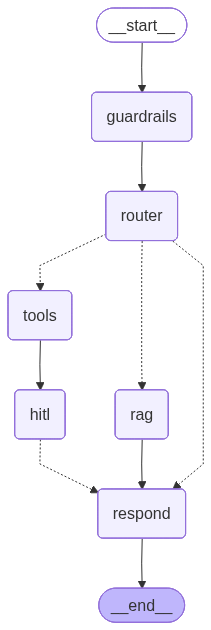

Graph rendered above!

NODES:
  - __start__
  - guardrails
  - router
  - rag
  - tools
  - hitl
  - respond
  - __end__

EDGES:
  - Edge(source='__start__', target='guardrails', data=None, conditional=False)
  - Edge(source='guardrails', target='router', data=None, conditional=False)
  - Edge(source='hitl', target='respond', data=None, conditional=True)
  - Edge(source='rag', target='respond', data=None, conditional=False)
  - Edge(source='router', target='rag', data=None, conditional=True)
  - Edge(source='router', target='respond', data=None, conditional=True)
  - Edge(source='router', target='tools', data=None, conditional=True)
  - Edge(source='tools', target='hitl', data=None, conditional=False)
  - Edge(source='respond', target='__end__', data=None, conditional=False)


In [20]:
# Visualize graph - renders PNG in Jupyter
from IPython.display import Image, display

try:
    # This renders the graph as an image directly in Jupyter
    graph_image = agent.get_graph(xray=True).draw_mermaid_png()
    display(Image(graph_image))
    print("Graph rendered above!")
except Exception as e:
    print(f"PNG rendering failed: {e}")
    print("Install: pip install grandalf")
    print("\nFalling back to ASCII...")
    try:
        print(agent.get_graph().draw_ascii())
    except:
        pass

print("\nNODES:")
for node in agent.get_graph().nodes:
    print(f"  - {node}")

print("\nEDGES:")
for edge in agent.get_graph().edges:
    print(f"  - {edge}")

In [21]:
# Alternative: Save graph as PNG file
try:
    graph_png = agent.get_graph(xray=True).draw_mermaid_png()
    with open('procurement_agent_graph.png', 'wb') as f:
        f.write(graph_png)
    print("Graph saved to: procurement_agent_graph.png")
except Exception as e:
    print(f"Could not save PNG: {e}")

# Print Mermaid code (for manual use at mermaid.live)
print("\nMERMAID CODE (copy to mermaid.live):")
print("-" * 40)
try:
    print(agent.get_graph().draw_mermaid())
except Exception as e:
    print(f"Mermaid not available: {e}")

Graph saved to: procurement_agent_graph.png

MERMAID CODE (copy to mermaid.live):
----------------------------------------
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	guardrails(guardrails)
	router(router)
	rag(rag)
	tools(tools)
	hitl(hitl)
	respond(respond)
	__end__([<p>__end__</p>]):::last
	__start__ --> guardrails;
	guardrails --> router;
	hitl -.-> respond;
	rag --> respond;
	router -.-> rag;
	router -.-> respond;
	router -.-> tools;
	tools --> hitl;
	respond --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



---
## Part 7: Run Agent

In [22]:
def ask_agent(agent, query: str, thread_id: str = None):
    """Send a query to the agent."""
    if thread_id is None:
        thread_id = str(uuid.uuid4())
    
    config = {'configurable': {'thread_id': thread_id}}
    
    print("\n" + "=" * 60)
    print(f"USER: {query}")
    print("=" * 60)
    
    initial_state = {
        'messages': [HumanMessage(content=query)],
        'intent': None,
        'tool_results': None,
        'rag_context': None,
        'requires_approval': False,
        'approval_status': None,
        'approval_reason': None,
        'po_number': None,
        'po_amount': None
    }
    
    result = agent.invoke(initial_state, config)
    
    print("\n" + "-" * 60)
    print("AGENT RESPONSE:")
    print("-" * 60)
    print(result['messages'][-1].content)
    
    return result, thread_id

In [23]:
# Test 1: Policy lookup (RAG)
ask_agent(agent, "What are the approval thresholds for purchase orders?")


USER: What are the approval thresholds for purchase orders?
  [Guardrails] Checking input...
    Input validated
  [Router] Classifying intent with LLM...
    Intent: policy_lookup
  [RAG] Searching policies...
    Found 3 relevant policy sections
  [Response] Generating answer...

------------------------------------------------------------
AGENT RESPONSE:
------------------------------------------------------------
Based on our procurement policies:

[Source 1: procurement_policies.md]
# Procurement Policy Manual

## Purchase Order Approval Thresholds

The following approval levels apply to all purchase orders:

- Orders under $10,000: Auto-approved by system
- Orders $10,000 to $50,000: Requires manager approval
- Orders $50,000 to $100,000: Requires director approval  
- Orders over $100,000: Requires VP approval
- Orders over $500,000: Requires CFO approval

## Vendor Requirements

All vendors must meet these requirements before purchase 


({'messages': [HumanMessage(content='What are the approval thresholds for purchase orders?', additional_kwargs={}, response_metadata={}, id='aec0984e-90d8-4655-b1b3-f33a5dc6fb43'),
   AIMessage(content='Based on our procurement policies:\n\n[Source 1: procurement_policies.md]\n# Procurement Policy Manual\n\n## Purchase Order Approval Thresholds\n\nThe following approval levels apply to all purchase orders:\n\n- Orders under $10,000: Auto-approved by system\n- Orders $10,000 to $50,000: Requires manager approval\n- Orders $50,000 to $100,000: Requires director approval  \n- Orders over $100,000: Requires VP approval\n- Orders over $500,000: Requires CFO approval\n\n## Vendor Requirements\n\nAll vendors must meet these requirements before purchase ', additional_kwargs={}, response_metadata={}, id='843835b1-1c59-4831-8352-66847ebcd3b4', tool_calls=[], invalid_tool_calls=[])],
  'intent': 'policy_lookup',
  'tool_results': None,
  'rag_context': '[Source 1: procurement_policies.md]\n# Proc

In [24]:
# Test 2: List POs (Tools)
ask_agent(agent, "List recent purchase orders")


USER: List recent purchase orders
  [Guardrails] Checking input...
    Input validated
  [Router] Classifying intent with LLM...
    Intent: po_query
  [Tools] Executing S/4HANA query...
    Listing POs...
  [HITL] Checking approval (threshold: $50,000)...
    Amount $0.00 within limit
  [Response] Generating answer...

------------------------------------------------------------
AGENT RESPONSE:
------------------------------------------------------------
Here are the Purchase Orders:
[
  {
    "po_number": "4500000001",
    "vendor": "USSU-VSF04",
    "vendor_name": "USSU-VSF04",
    "amount": 211949.01,
    "currency": "USD",
    "item_count": 9
  },
  {
    "po_number": "4500000002",
    "vendor": "USSU-VSF02",
    "vendor_name": "WaveCrest Labs",
    "amount": 101080.63,
    "currency": "USD",
    "item_count": 9
  },
  {
    "po_number": "4500000003",
    "vendor": "USSU-VSF01",
    "vendor_name": "EV Parts Inc.",
    "amount": 20878.730000000003,
    "currency": "USD",
    "item

({'messages': [HumanMessage(content='List recent purchase orders', additional_kwargs={}, response_metadata={}, id='71cc646b-2b05-4401-a61d-8d2b70a4232e'),
   AIMessage(content='Here are the Purchase Orders:\n[\n  {\n    "po_number": "4500000001",\n    "vendor": "USSU-VSF04",\n    "vendor_name": "USSU-VSF04",\n    "amount": 211949.01,\n    "currency": "USD",\n    "item_count": 9\n  },\n  {\n    "po_number": "4500000002",\n    "vendor": "USSU-VSF02",\n    "vendor_name": "WaveCrest Labs",\n    "amount": 101080.63,\n    "currency": "USD",\n    "item_count": 9\n  },\n  {\n    "po_number": "4500000003",\n    "vendor": "USSU-VSF01",\n    "vendor_name": "EV Parts Inc.",\n    "amount": 20878.730000000003,\n    "currency": "USD",\n    "item_count": 9\n  },\n  {\n    "po_number": "4500000004",\n    "vendor": "USSU-VSF05",\n    "vendor_name": "VF Vendor 05",\n    "amount": 66907.40000000001,\n    "currency": "USD",\n    "item_count": 10\n  },\n  {\n    "po_number": "4500000005",\n    "vendor": "US

In [25]:
# Test 3: Specific PO (Tools + HITL)
ask_agent(agent, "Show me details for PO 4500000001")


USER: Show me details for PO 4500000001
  [Guardrails] Checking input...
    Input validated
  [Router] Classifying intent with LLM...
    Intent: po_query
  [Tools] Executing S/4HANA query...
    Found PO number: 4500000001
  [HITL] Checking approval (threshold: $50,000)...
    Amount $211,949.01 exceeds threshold!
    Triggering SAP BPA workflow...
    Getting BPA OAuth token...
    Workflow triggered! Instance ID: 8098325c-2bbc-11f1-b381-eeee0a89e069
  [Response] Generating answer...

------------------------------------------------------------
AGENT RESPONSE:
------------------------------------------------------------
Purchase Order Details:
{
  "po_number": "4500000001",
  "vendor": "USSU-VSF04",
  "vendor_name": "USSU-VSF04",
  "amount": 211949.01,
  "currency": "USD",
  "status": "02",
  "company_code": "1710",
  "item_count": 9
}


*** APPROVAL REQUIRED ***
PO $211,949.01 exceeds threshold. Instance: 8098325c-2bbc-11f1-b381-eeee0a89e069


({'messages': [HumanMessage(content='Show me details for PO 4500000001', additional_kwargs={}, response_metadata={}, id='a3f3b599-aa9e-403b-8145-f7804c581436'),
   AIMessage(content='Purchase Order Details:\n{\n  "po_number": "4500000001",\n  "vendor": "USSU-VSF04",\n  "vendor_name": "USSU-VSF04",\n  "amount": 211949.01,\n  "currency": "USD",\n  "status": "02",\n  "company_code": "1710",\n  "item_count": 9\n}\n\n\n*** APPROVAL REQUIRED ***\nPO $211,949.01 exceeds threshold. Instance: 8098325c-2bbc-11f1-b381-eeee0a89e069', additional_kwargs={}, response_metadata={}, id='a821918b-2a9a-4d74-9e75-0d00bdf23ffc', tool_calls=[], invalid_tool_calls=[])],
  'intent': 'po_query',
  'tool_results': {'po_number': '4500000001',
   'vendor': 'USSU-VSF04',
   'vendor_name': 'USSU-VSF04',
   'amount': 211949.01,
   'currency': 'USD',
   'status': '02',
   'company_code': '1710',
   'item_count': 9},
  'rag_context': None,
  'requires_approval': True,
  'approval_status': 'pending_bpa',
  'approval_rea

In [26]:
# Test 4: Amount filter
ask_agent(agent, "Show purchase orders over 100000")


USER: Show purchase orders over 100000
  [Guardrails] Checking input...
    Input validated
  [Router] Classifying intent with LLM...
    Intent: po_query
  [Tools] Executing S/4HANA query...
    Amount filter: gt $100,000
    Listing POs...
  [HITL] Checking approval (threshold: $50,000)...
    Amount $0.00 within limit
  [Response] Generating answer...

------------------------------------------------------------
AGENT RESPONSE:
------------------------------------------------------------
Here are the Purchase Orders:
[
  {
    "po_number": "4500000001",
    "vendor": "USSU-VSF04",
    "vendor_name": "USSU-VSF04",
    "amount": 211949.01,
    "currency": "USD",
    "item_count": 9
  },
  {
    "po_number": "4500000002",
    "vendor": "USSU-VSF02",
    "vendor_name": "WaveCrest Labs",
    "amount": 101080.63,
    "currency": "USD",
    "item_count": 9
  },
  {
    "po_number": "4500000005",
    "vendor": "USSU-VSF06",
    "vendor_name": "VF Vendor 06",
    "amount": 180323.4200000000

({'messages': [HumanMessage(content='Show purchase orders over 100000', additional_kwargs={}, response_metadata={}, id='4c92ea71-9b6b-45d7-947f-7439ec8be14b'),
   AIMessage(content='Here are the Purchase Orders:\n[\n  {\n    "po_number": "4500000001",\n    "vendor": "USSU-VSF04",\n    "vendor_name": "USSU-VSF04",\n    "amount": 211949.01,\n    "currency": "USD",\n    "item_count": 9\n  },\n  {\n    "po_number": "4500000002",\n    "vendor": "USSU-VSF02",\n    "vendor_name": "WaveCrest Labs",\n    "amount": 101080.63,\n    "currency": "USD",\n    "item_count": 9\n  },\n  {\n    "po_number": "4500000005",\n    "vendor": "USSU-VSF06",\n    "vendor_name": "VF Vendor 06",\n    "amount": 180323.42000000004,\n    "currency": "USD",\n    "item_count": 10\n  },\n  {\n    "po_number": "4500000007",\n    "vendor": "USSU-VSF08",\n    "vendor_name": "VF Vendor 08",\n    "amount": 232934.0,\n    "currency": "USD",\n    "item_count": 7\n  }\n]', additional_kwargs={}, response_metadata={}, id='04cc395f

In [27]:
# Test 5: General greeting
ask_agent(agent, "Hello, what can you help me with?")


USER: Hello, what can you help me with?
  [Guardrails] Checking input...
    Input validated
  [Router] Classifying intent with LLM...
    Intent: general
  [Response] Generating answer...

------------------------------------------------------------
AGENT RESPONSE:
------------------------------------------------------------
I can help you with purchase orders and procurement policies. What would you like to know?


({'messages': [HumanMessage(content='Hello, what can you help me with?', additional_kwargs={}, response_metadata={}, id='743c1250-467b-43d0-892d-6974522e8bbc'),
   AIMessage(content='I can help you with purchase orders and procurement policies. What would you like to know?', additional_kwargs={}, response_metadata={}, id='ff4e8f78-9e9b-47c8-a0ee-bdc959636189', tool_calls=[], invalid_tool_calls=[])],
  'intent': 'general',
  'tool_results': None,
  'rag_context': None,
  'requires_approval': False,
  'approval_status': None,
  'approval_reason': None,
  'po_number': None,
  'po_amount': None},
 '31402ed6-630f-41f7-93aa-2be9950bf924')

---
## Part 8: Streaming Execution

In [28]:
def stream_agent(agent, query: str):
    """Stream agent execution showing each step."""
    print("\n" + "=" * 60)
    print(f"STREAMING: {query}")
    print("=" * 60)
    
    initial_state = {
        'messages': [HumanMessage(content=query)],
        'intent': None,
        'tool_results': None,
        'rag_context': None,
        'requires_approval': False,
        'approval_status': None,
        'approval_reason': None,
        'po_number': None,
        'po_amount': None
    }
    
    config = {'configurable': {'thread_id': str(uuid.uuid4())}}
    
    for event in agent.stream(initial_state, config):
        for node_name, node_output in event.items():
            print(f"\n>> NODE: {node_name}")
            if node_output and isinstance(node_output, dict):
                print(f"   Keys: {list(node_output.keys())}")
                if 'intent' in node_output:
                    print(f"   Intent: {node_output['intent']}")
                if 'requires_approval' in node_output:
                    print(f"   Requires approval: {node_output['requires_approval']}")

# Stream a query
stream_agent(agent, "What are the payment terms for vendors?")


STREAMING: What are the payment terms for vendors?
  [Guardrails] Checking input...
    Input validated

>> NODE: guardrails
  [Router] Classifying intent with LLM...
    Intent: policy_lookup

>> NODE: router
   Keys: ['intent']
   Intent: policy_lookup
  [RAG] Searching policies...
    Found 3 relevant policy sections

>> NODE: rag
   Keys: ['rag_context']
  [Response] Generating answer...

>> NODE: respond
   Keys: ['messages']


---
## Summary

**What We Built:**
1. **LangGraph Agent** with state machine architecture
2. **Guardrails** for input validation and PII masking
3. **LLM Router** for intent classification
4. **RAG System** for policy document retrieval
5. **S/4HANA Integration** for purchase order data
6. **HITL Check** with SAP BPA workflow trigger

**Key Patterns:**
- `StateGraph` for defining agent workflow
- `add_messages` annotation for conversation history
- Conditional edges for dynamic routing
- `MemorySaver` for checkpointing

**Next Steps:**
- Deploy to Cloud Foundry or Kyma
- Add more tools (vendor lookup, GR posting)
- Integrate with SAP HANA Vector Engine for production RAG
- Add LangSmith observability